In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('heart.csv')

In [3]:
df.columns.tolist()

['Age',
 'Sex',
 'ChestPainType',
 'RestingBP',
 'Cholesterol',
 'FastingBS',
 'RestingECG',
 'MaxHR',
 'ExerciseAngina',
 'Oldpeak',
 'ST_Slope',
 'HeartDisease']

In [4]:
print('=== Missing Values ===')
print(df.isnull().sum())

print('\n=== Data Types ===')
print(df.dtypes)

print('\n=== Basic Statistics ===')
df.describe()

=== Missing Values ===
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

=== Data Types ===
Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

=== Basic Statistics ===


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,accuracy_score)
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [6]:
# Drop rows with missing values
df.dropna(inplace=True)

# Drop duplicate rows
df.drop_duplicates(inplace=True)

# Encode any text/categorical columns to numbers
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])
    print(f'Encoded column: {col}')

df.reset_index(drop=True, inplace=True)
print('\nCleaned shape:', df.shape)
df.head()

Encoded column: Sex
Encoded column: ChestPainType
Encoded column: RestingECG
Encoded column: ExerciseAngina
Encoded column: ST_Slope

Cleaned shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1,140,289,0,1,172,0,0.0,2,0
1,49,0,2,160,180,0,1,156,0,1.0,1,1
2,37,1,1,130,283,0,2,98,0,0.0,2,0
3,48,0,0,138,214,0,1,108,1,1.5,1,1
4,54,1,2,150,195,0,1,122,0,0.0,2,0


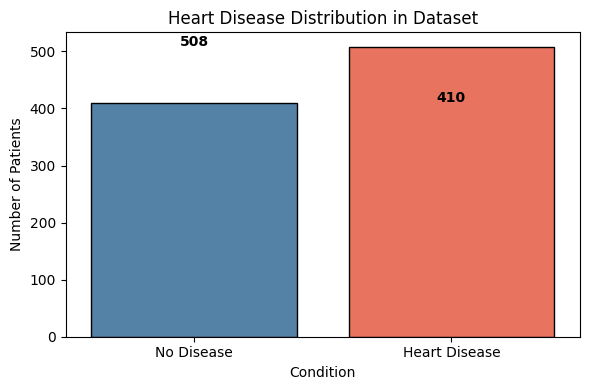


No Disease    : 410
Heart Disease : 508


In [7]:
# 'target' column: 1 = Heart Disease, 0 = No Disease
target_col = 'HeartDisease'   # change if your column is named differently

counts = df[target_col].value_counts()

plt.figure(figsize=(6, 4))
sns.barplot(x=counts.index, y=counts.values,
            palette=['steelblue', 'tomato'], edgecolor='black')
plt.xticks([0, 1], ['No Disease', 'Heart Disease'])
plt.title('Heart Disease Distribution in Dataset')
plt.xlabel('Condition')
plt.ylabel('Number of Patients')
for i, v in enumerate(counts.values):
    plt.text(i, v + 2, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nNo Disease    : {counts[0]}')
print(f'Heart Disease : {counts[1]}')

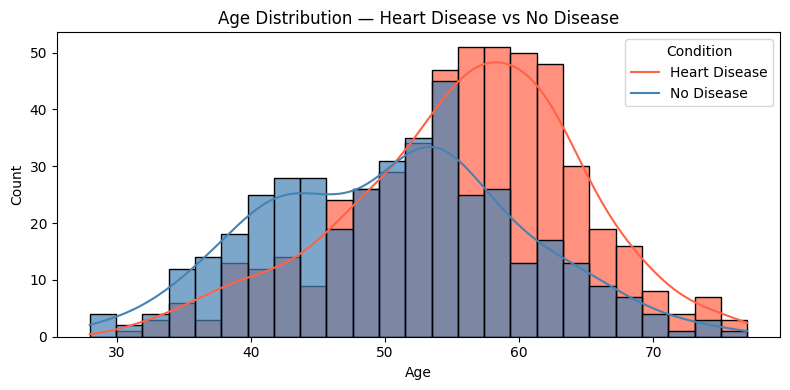

In [8]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='Age', hue=target_col, bins=25,
             kde=True, palette={0: 'steelblue', 1: 'tomato'}, alpha=0.7)
plt.title('Age Distribution — Heart Disease vs No Disease')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title='Condition', labels=['Heart Disease', 'No Disease'])
plt.tight_layout()
plt.show()

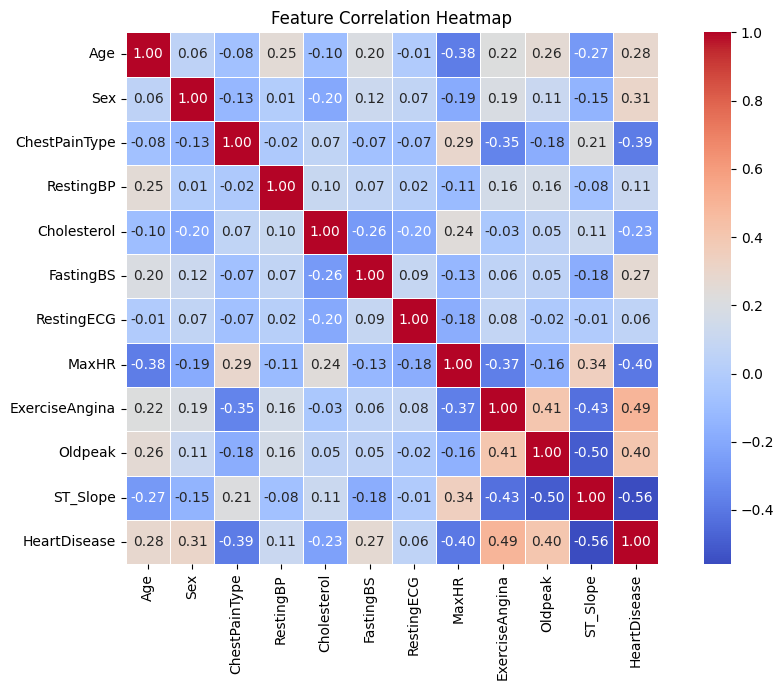

In [9]:
plt.figure(figsize=(10, 7))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()